In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
from matplotlib.gridspec import GridSpec
import matplotlib.image as image
from scipy import stats

In [2]:
# caution: path[0] is reserved for script path 
sys.path.insert(1, './utils/')

In [3]:
from load_data import *
from plot_functions import *
from utils_functions import *

In [4]:
IDs_control = ['1','2','3','4','5']
IDs_c1 = ['11','12','13','14','15']
IDs_c2 = ['21','22','23','24']

IDs_c3 =['29', '30', '31', '32', '33']
IDs_c4 = ['39', '40', '41', '42', '43']


frequencies = [6,8,10,12,16]

In [17]:
# load cells dict 

filename = f"../data_experiments/data_OSR_cells_ON_luminance.pkl"
with open(filename, "rb") as handle:   #Pickling
   cells_dict =  pickle.load(handle)


In [21]:
save = True
save_name = "../Figures/Figure_21"
show = True
image_format = "png"
dpi = 300

In [22]:

#figure parameter

fontsize_legend = 20
fontsize_labels = 25
fontsize_panellabel = 40
fontsize_ticks = 20
lw = 4
lwthin = 2
ms = 60
panellabel_position = [-0.1, 1.15]
frequencytext_position = [0.15,1.4]
nrows = 14
ncols = 6

figsize_ratio = 3
figsize = (18,20)



condition1 = 'equiluminance_flashduration'
condition2 = 'equiluminance_interflashinterval'

colr = 'green'
colr2 = 'blue'
colr3 = 'darkorange'
colr4 = 'deeppink'
periods = np.array([170,120,100,80,60])

ref = -2
example_cell = 'cell_11'



# Luminance Results Panel 

luminaince = 3.552713678800501e-15
luminaince = 3.552713678800501e-15


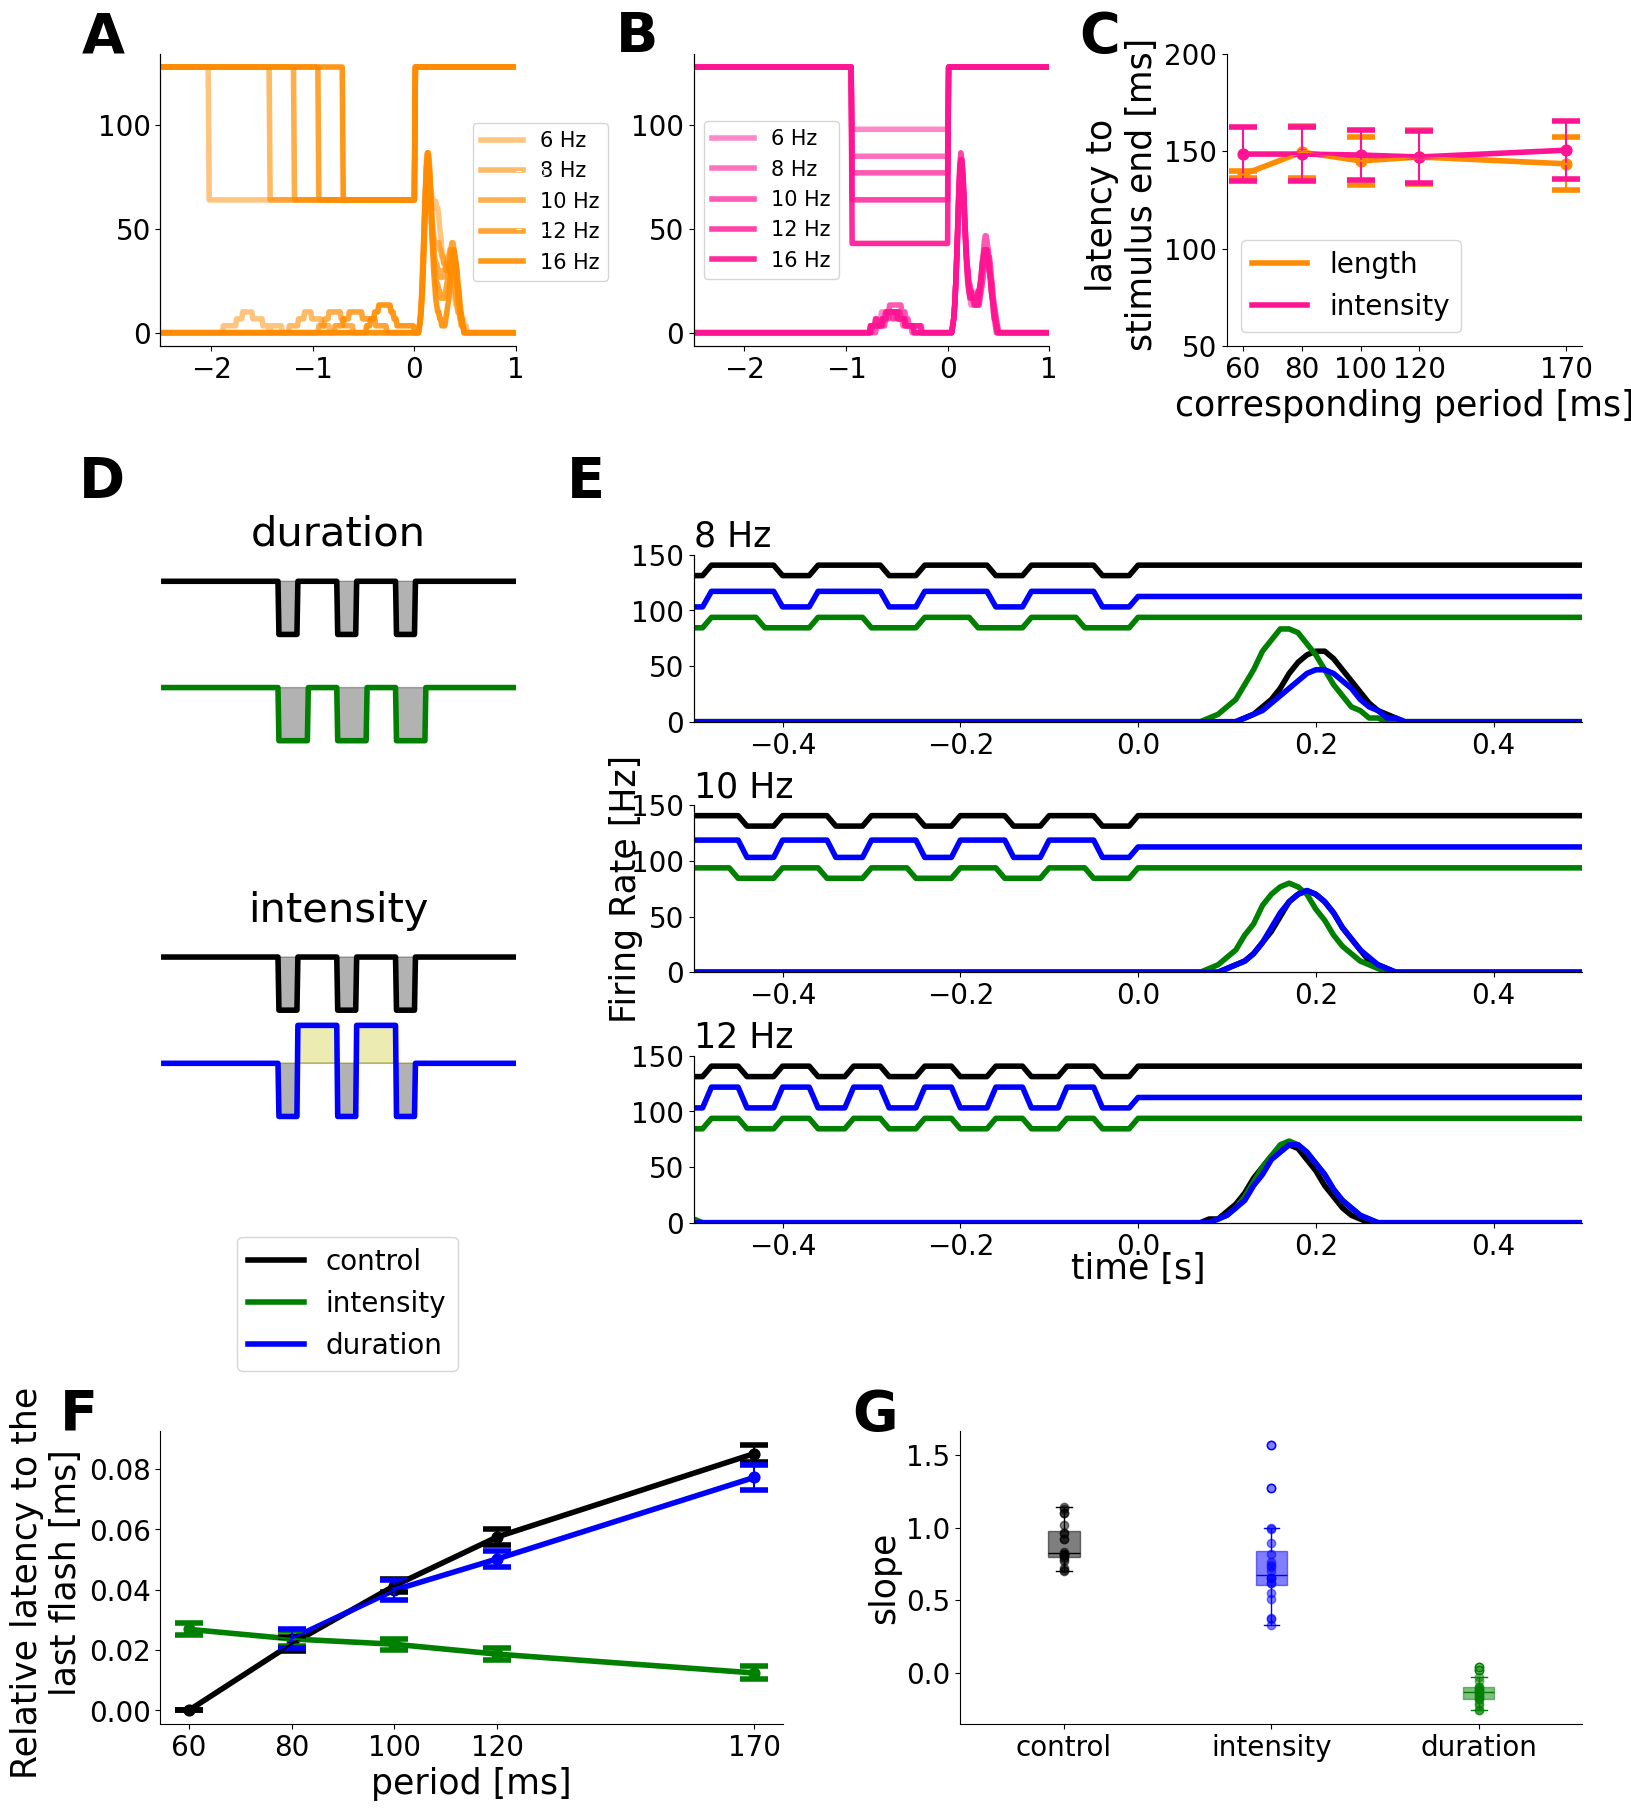

In [23]:


#initialize figure
fig = plt.figure(figsize=figsize)
fig.patch.set_facecolor('white')


gs = fig.add_gridspec(nrows,ncols)
fig.tight_layout()


fig.subplots_adjust(
top=0.945,
bottom=0.11,
left=0.11,
right=0.9,
hspace=2.,
wspace= 2
)

#####################################################################################################################
# create panels
#####################################################################################################################


A = fig.add_subplot(gs[:3,0:2])
B = fig.add_subplot(gs[:3,2:4])

C = fig.add_subplot(gs[:3,4:6])



D = fig.add_subplot(gs[4:10,0:2], frameon = False)
D0 = fig.add_subplot(gs[4:7,0:2])
D1 = fig.add_subplot(gs[7:10,0:2], sharex = D0,sharey = D0)

E = fig.add_subplot(gs[4:10,2:], frameon = False)
E0 = fig.add_subplot(gs[4:6,2:])
E1 = fig.add_subplot(gs[6:8,2:], sharey = E0, sharex = E0)
E2 = fig.add_subplot(gs[8:10,2:], sharey = E0, sharex = E0)


F = fig.add_subplot(gs[11:,0:3])


G = fig.add_subplot(gs[11:,3:])



#####################################################################################################################
# PANEL A: step duration
#####################################################################################################################

if "A" in globals():
    ax = A
    #add panel labels
    ax.text(panellabel_position[0],panellabel_position[1], "A", transform=ax.transAxes,
          fontsize=fontsize_panellabel, fontweight='bold', va='top', ha='right')



ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
#ax.tick_params(axis='x', colors='white')
ax.set_xlim(-2.5,1)

cmap3 =  plt.get_cmap('Blues',6)

condition = 'luminance_step_length_test'


for x,ID in enumerate(IDs_c3):
    
    time = cells_dict['stimulus_info'][ID]['osr_time'] - cells_dict['stimulus_info'][ID]['lastflashend']
    response_control = cells_dict['cells'][example_cell]['response_data'][f'{condition}'][ID]['rate_smoothed']
    ax.plot(time,response_control, color = colr3, linewidth = lw, label = f'{frequencies[x]} Hz', alpha = x*0.1+0.5)
    #ax.axvline(cells_dict['cells'][example_cell]['slope_data'][f'peaks_{condition}'][x], color = colr, alpha = .5, linewidth = 5 )


ax2 = ax.twinx()
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.tick_params(axis='y', colors='white')


for x,ID in enumerate(IDs_c3):

    time = cells_dict['stimulus_info'][ID]['osr_time'] - cells_dict['stimulus_info'][ID]['lastflashend']
    stim = cells_dict['stimulus'][ID].dropna()

    ax.plot(time,stim, color =colr3, linewidth = lw, alpha = x*0.1+0.5)

ax.legend(fontsize = fontsize_legend-5, bbox_to_anchor=(.85,.8))


#####################################################################################################################
# PANEL A: step intensity
#####################################################################################################################

if "B" in globals():
    ax = B
    #add panel labels
    ax.text(panellabel_position[0],panellabel_position[1], "B", transform=ax.transAxes,
          fontsize=fontsize_panellabel, fontweight='bold', va='top', ha='right')



ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
#ax.tick_params(axis='x', colors='white')
ax.set_xlim(-2.5,1)

cmap4 =  plt.get_cmap('Greens',6)

condition = 'luminance_step_intensity_test'


for x,ID in enumerate(IDs_c4):
    time = cells_dict['stimulus_info'][ID]['osr_time'] - cells_dict['stimulus_info'][ID]['lastflashend']
    response_control = cells_dict['cells'][example_cell]['response_data'][f'{condition}'][ID]['rate_smoothed']
    ax.plot(time,response_control, color = colr4, linewidth = lw, label = f'{frequencies[x]} Hz', alpha = x*0.1+0.5)
    #ax.axvline(cells_dict['cells'][example_cell]['slope_data'][f'peaks_{condition}'][x], color = colr, alpha = .5, linewidth = 5 )


ax2 = ax.twinx()
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.tick_params(axis='y', colors='white')


for x,ID in enumerate(IDs_c4):

    time = cells_dict['stimulus_info'][ID]['osr_time'] - cells_dict['stimulus_info'][ID]['lastflashend']
    stim = cells_dict['stimulus'][ID].dropna()

    ax.plot(time,stim, color = colr4, linewidth = lw, alpha = x*0.1+0.5)


ax.legend(fontsize = fontsize_legend-5)



#####################################################################################################################
# PANEL C: latency stimulus end
#####################################################################################################################

if "C" in globals():
    ax = C
    #add panel labels
    ax.text(panellabel_position[0]-.2,panellabel_position[1], "C", transform=ax.transAxes,
          fontsize=fontsize_panellabel, fontweight='bold', va='top', ha='right')



conditions = ['luminance_step_length_test','luminance_step_intensity_test']


#latenciesc = cells_dict['mean']['mean_peaks_control']*1000
latencieseq1 = cells_dict['mean'][f'mean_peaks_{conditions[0]}']*1000 
latencieseq2 = cells_dict['mean'][f'mean_peaks_{conditions[1]}'][:-2]*1000 

#stdc = cells_dict['std']['std_peaks_control']*1000
stdq1 = cells_dict['std'][f'std_peaks_{conditions[0]}']*1000
stdq2 = cells_dict['std'][f'std_peaks_{conditions[1]}'][:-2]*1000


#remove frames that are not needed
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
#
ax.locator_params(axis='x', nbins=3)

# Label the axis
ax.set_ylabel('latency to \n stimulus end [ms]',fontsize = fontsize_labels)
ax.set_xlabel('corresponding period [ms]',fontsize = fontsize_labels)

ax.set_xticks(periods[::-1])

ax.tick_params('x', labelsize=fontsize_ticks)
ax.tick_params('y', labelsize=fontsize_ticks)
ax.set_ylim(50,200)

# # plot data
# ax.plot(periods,latenciesc,color = 'black',linewidth = lw)
# ax.scatter(periods,latenciesc, color = 'black', s = ms)

ax.plot(periods,latencieseq1,color = colr3,linewidth = lw, label = 'length')
ax.scatter(periods,latencieseq1, color = colr3, s = ms)


ax.plot(periods,latencieseq2,color = colr4,linewidth = lw, label = 'intensity')
ax.scatter(periods,latencieseq2, color = colr4, s = ms)

# std data
#ax.errorbar(periods,latenciesc, yerr = stdc, capsize = 10, capthick = lw, color = 'black')
ax.errorbar(periods,latencieseq1, yerr = stdq1, capsize = 10, capthick = lw, color = colr3)
ax.errorbar(periods,latencieseq2, yerr = stdq2, capsize = 10, capthick = lw, color = colr4)
ax.legend(fontsize = fontsize_legend)







#####################################################################################################################
# PANEL C: stimulus modifications 
#####################################################################################################################

if "D" in globals():
    ax = D
    #add panel labels
    ax.text(panellabel_position[0],panellabel_position[1], "D", transform=ax.transAxes,
          fontsize=fontsize_panellabel, fontweight='bold', va='top', ha='right')


ax.spines['left'].set_color('white')
ax.tick_params(axis='y', colors='white')
ax.spines['bottom'].set_color('white')
ax.tick_params(axis='x', colors='white')


ax = D0
ax.set_title('duration', fontsize = 30)

#remove frames that are not needed
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_color('white')
ax.tick_params(axis='y', colors='white')
ax.spines['bottom'].set_color('white')
ax.tick_params(axis='x', colors='white')


freq = 8
fl = 3

# control
stim0,time,_ = periodic_flashes(freq, fl, dt = 0.002)


# variable flashlength 
stim1, time1,_ = periodic_flashes_variable_flashlength(freq, fl, dt = 0.002)


# intervals 
stim2,time2,_ = periodic_flashes_fixed_luminance(freq, fl, luminance_ratio = 1.,dt = 0.002)


stim0 = stim0 
stim1 = stim1 +ref
#stim2 = stim2 -2
ax.plot(time,stim0, color = 'black', linewidth = lw)
ax.fill_between(time,stim0, color= 'k', alpha = 0.3)



ax.plot(time1,stim1, color = colr, linewidth = lw)
ax.fill_between(time1,stim1,y2 = ref, color= 'k', alpha = 0.3)

#ax.plot(time2,stim2, color = colr2, linewidth = lw)
#ax.axvline(2+0.04, color = 'k', linestyle = ':')
ax.set_ylim(-10,6)



ax = D1
ax.set_title('intensity', fontsize = 30)
#remove frames that are not needed
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_color('white')
ax.tick_params(axis='y', colors='white')
ax.spines['bottom'].set_color('white')
ax.tick_params(axis='x', colors='white')


# control
stim0,time,_ = periodic_flashes(freq, fl, dt = 0.002)

t = time[:-1]
starts0 = t[np.diff(stim0)==-1]
ends0 = t[np.diff(stim0)==1]

# variable flashlength 
stim1, time1,_ = periodic_flashes_variable_flashlength(freq, fl, dt = 0.002)

starts1 = t[np.diff(stim1)<0]
ends1 = t[np.diff(stim1)>0]


# intervals 
stim2,time2,_ = periodic_flashes_fixed_luminance(freq, fl, luminance_ratio = 1.,dt = 0.002)


starts2 = t[np.diff(stim2)<0]
ends2 = t[np.diff(stim2)>0]

stim0 = stim0 
#stim1 = stim1 -2
stim2 = stim2 +ref
ax.plot(time,stim0, color = 'black', linewidth = lw)
ax.fill_between(time,stim0, color= 'k', alpha = 0.3)
# for f in range(len(starts0)):
#     ax.axvspan(starts0[f],ends0[f],-1,0) # highlight low luminance periods 


#ax.plot(time1,stim1, color = colr, linewidth = lw)
ax.plot(time2,stim2,color = colr2, linewidth = lw)
stim2fy = np.where(stim2>ref,stim2,ref)
stim2fk = np.where(stim2<ref,stim2,ref)
ax.fill_between(time,stim2fk,y2 = ref, color= 'k', alpha = 0.3)
ax.fill_between(time,stim2fy,y2 = ref, color= 'y', alpha = 0.3)
#ax.fill_between(time,stim2[np.nonzero(stim2 < -3)[0]],y2 = -3, color= 'k', alpha = 0.3)

# ax.axhline(0, color = 'k', linestyle = ':', linewidth = lw)
# ax.axhline(-2, color = 'k', linestyle = ':', linewidth = lw)
# ax.spines['right'].set_visible(False)
# ax.spines['top'].set_visible(False)
ax.tick_params(axis='y', colors='white')
ax.set_ylim(-5.,0.5)
ax.set_xlim(1.75,2.5)

#####################################################################################################################
# PANEL D: response traces
#####################################################################################################################
if "E" in globals():
    ax =E
    
    ax.text(*panellabel_position, "E", transform=ax.transAxes,
          fontsize=fontsize_panellabel, fontweight='bold', va='top', ha='right')

   


# plot with stimuli


ax = E
ax.scatter([0,1000],[0,1000], color = 'white')


#remove frames that are not needed
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_color('white')
ax.tick_params(axis='y', colors='white')
ax.spines['bottom'].set_color('white')
ax.tick_params(axis='x', colors='white')

# Label the axis
ax.set_ylabel('Firing Rate [Hz]',fontsize = fontsize_labels)
ax.set_xlabel('time [s]',fontsize = fontsize_labels)
    

#6 Hz
ax = E0
#remove frames that are not needed
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# ax.tick_params('x', labelbottom=False)


# set axis range
ax.set_xlim(-.5,.5)

# plot traces control
ID = '2'
time = cells_dict['stimulus_info'][ID]['osr_time'] - cells_dict['stimulus_info'][ID]['lastflashend']
stim0 = cells_dict['stimulus'][ID].dropna()
response_control = cells_dict['cells'][example_cell]['response_data']['control'][ID]['rate_smoothed']
ax.plot(time,response_control, color = 'black', linewidth = lw, label = 'control')
#ax.axvline(cells_dict['cells'][example_cell]['slope_data']['peaks_control'][0], color = 'k', alpha = .5, linewidth = 5 )
response6_classic = response_control

# plot traces equiluminance
ID = '12'
time1 = cells_dict['stimulus_info'][ID]['osr_time'] - cells_dict['stimulus_info'][ID]['lastflashend']
stim1 = cells_dict['stimulus'][ID].dropna()
response_control = cells_dict['cells'][example_cell]['response_data'][f'{condition1}'][ID]['rate_smoothed']
ax.plot(time1,response_control, color = colr, linewidth = lw, label = 'duration')
#ax.axvline(cells_dict['cells'][example_cell]['slope_data'][f'peaks_{condition1}'][0], color = colr, alpha = .5, linewidth = 5 )



ID = '22'
time = cells_dict['stimulus_info'][ID]['osr_time'] - cells_dict['stimulus_info'][ID]['lastflashend']
stim2 = cells_dict['stimulus'][ID].dropna()
response_control = cells_dict['cells'][example_cell]['response_data'][f'{condition2}'][ID]['rate_smoothed']
ax.plot(time,response_control, color = colr2, linewidth = lw, label = 'intensity')
#ax.axvline(cells_dict['cells'][example_cell]['slope_data'][f'peaks_{condition2}'][0], color = colr2, alpha = .5, linewidth = 5 )
response6_mean = response_control


#ax2 = A0s
ax2 = ax.twinx()
ax2.set_title( f'8 Hz', fontsize=fontsize_labels, loc='left') 

stim0 = (stim0-128)/128 +5
stim1 = (stim1-128)/128 
stim2 = (stim2-128)/128 +2
ax2.plot(time,stim0, color = 'black', linewidth = lw)
ax2.plot(time1,stim1, color = colr, linewidth = lw)
ax2.plot(time,stim2, color = colr2, linewidth = lw)
stim6_classic = stim0
stim6_mean = stim2

ax2.spines['right'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax2.tick_params(axis='y', colors='white')
ax2.set_ylim(-10,6)
ax.set_ylim(0,50)




#10 Hz
ax = E1
#remove frames that are not needed
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

#ax.tick_params('x', labelbottom=False)


    # set axis range


# plot traces control
ID = '3'
time = cells_dict['stimulus_info'][ID]['osr_time'] - cells_dict['stimulus_info'][ID]['lastflashend']
stim0 = cells_dict['stimulus'][ID].dropna()
response_control = cells_dict['cells'][example_cell]['response_data']['control'][ID]['rate_smoothed']
ax.plot(time,response_control, color = 'black', linewidth = lw)
#ax.axvline(cells_dict['cells'][example_cell]['slope_data']['peaks_control'][0], color = 'k', alpha = .5, linewidth = 5 )
response10_classic = response_control



# plot traces equiluminance
ID = '13'
time1 = cells_dict['stimulus_info'][ID]['osr_time'] - cells_dict['stimulus_info'][ID]['lastflashend']
stim1 = cells_dict['stimulus'][ID].dropna()
response_control = cells_dict['cells'][example_cell]['response_data'][f'{condition1}'][ID]['rate_smoothed']
ax.plot(time1,response_control, color = colr, linewidth = lw)
#ax.axvline(cells_dict['cells'][example_cell]['slope_data'][f'peaks_{condition1}'][0], color = colr, alpha = .5, linewidth = 5 )



ID = '23'
time = cells_dict['stimulus_info'][ID]['osr_time'] - cells_dict['stimulus_info'][ID]['lastflashend']
stim2 = cells_dict['stimulus'][ID].dropna()
response_control = cells_dict['cells'][example_cell]['response_data'][f'{condition2}'][ID]['rate_smoothed']
ax.plot(time,response_control, color = colr2, linewidth = lw)
#ax.axvline(cells_dict['cells'][example_cell]['slope_data'][f'peaks_{condition2}'][0], color = colr2, alpha = .5, linewidth = 5 )
response10_mean = response_control


#ax2 = A1s

ax2 = ax.twinx()

stim0 = (stim0-128)/128 +5
stim1 = (stim1-128)/128 
stim2 = (stim2-128)/128 +2
ax2.plot(time,stim0, color = 'black', linewidth = lw)
ax2.plot(time1,stim1, color = colr, linewidth = lw)
ax2.plot(time,stim2, color = colr2, linewidth = lw)
stim10_classic = stim0
stim10_mean = stim2


ax2.spines['right'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax2.tick_params(axis='y', colors='white')
ax2.set_ylim(-10,6)
ax.set_ylim(0,50)

ax2.set_title( f'10 Hz', fontsize=fontsize_labels, loc='left') 


#12 Hz
ax = E2

#remove frames that are not needed
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

#ax.tick_params('x', labelbottom=False)
ax.locator_params(axis='x', nbins=5)

ID = '4'
time = cells_dict['stimulus_info'][ID]['osr_time'] - cells_dict['stimulus_info'][ID]['lastflashend']
stim0 = cells_dict['stimulus'][ID].dropna()
response_control = cells_dict['cells'][example_cell]['response_data']['control'][ID]['rate_smoothed']
ax.plot(time,response_control, color = 'black', linewidth = lw, label = 'control')
#ax.axvline(cells_dict['cells'][example_cell]['slope_data']['peaks_control'][0], color = 'k', alpha = .5, linewidth = 5 )
response12_classic = response_control



# plot traces equiluminance
ID = '14'
time1 = cells_dict['stimulus_info'][ID]['osr_time'] - cells_dict['stimulus_info'][ID]['lastflashend']
stim1 = cells_dict['stimulus'][ID].dropna()
response_control = cells_dict['cells'][example_cell]['response_data'][f'{condition1}'][ID]['rate_smoothed']
ax.plot(time1,response_control, color = colr, linewidth = lw, label = 'intensity')
#ax.axvline(cells_dict['cells'][example_cell]['slope_data'][f'peaks_{condition1}'][0], color = colr, alpha = .5, linewidth = 5 )



ID = '24'
time = cells_dict['stimulus_info'][ID]['osr_time'] - cells_dict['stimulus_info'][ID]['lastflashend']
stim2 = cells_dict['stimulus'][ID].dropna()
response_control = cells_dict['cells'][example_cell]['response_data'][f'{condition2}'][ID]['rate_smoothed']
ax.plot(time,response_control, color = colr2, linewidth = lw,label ='duration')
#ax.axvline(cells_dict['cells'][example_cell]['slope_data'][f'peaks_{condition2}'][0], color = colr2, alpha = .5, linewidth = 5 )
response12_mean = response_control


#ax2 = A2s
ax2 = ax.twinx()

ax2.set_title( f'12 Hz', fontsize=fontsize_labels, loc='left') 


stim0 = (stim0-128)/128 +5
stim1 = (stim1-128)/128 
stim2 = (stim2-128)/128 +2
ax2.plot(time,stim0, color = 'black', linewidth = lw)
ax2.plot(time1,stim1, color = colr, linewidth = lw)
ax2.plot(time,stim2, color = colr2, linewidth = lw)
stim12_classic = stim0
stim12_mean = stim2


ax2.spines['right'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax2.tick_params(axis='y', colors='white')
ax2.set_ylim(-10,6)
ax.set_ylim(0,150)


for ax in [E0,E1,E2]:
        ax.tick_params('x', labelsize=fontsize_ticks)
        ax.tick_params('y', labelsize=fontsize_ticks)

#fig.legend(fontsize =fontsize_legend)

    
ax.legend(fontsize = fontsize_legend, bbox_to_anchor=(-.25,0))

#####################################################################################################################
# PANEL C : latency plot
#####################################################################################################################


if "F" in globals():

    ax = F
    #add panel label
    ax.text(panellabel_position[0],panellabel_position[1], "F", transform=ax.transAxes,
          fontsize=fontsize_panellabel, fontweight='bold', va='top', ha='right')

    latenciesc = cells_dict['mean']['mean_peaks_control']
    latencieseq1 = cells_dict['mean'][f'mean_peaks_{condition1}']
    latencieseq2 = cells_dict['mean'][f'mean_peaks_{condition2}']

    stdc = cells_dict['std']['std_peaks_control']
    stdq1 = cells_dict['std'][f'std_peaks_{condition1}']
    stdq2 = cells_dict['std'][f'std_peaks_{condition2}']


    #add panel label
    # ax.text(*panellabel_position, "A", transform=ax.transAxes,
    #         fontsize=fontsize_panellabel, fontweight='bold', va='top', ha='right')
    #remove frames that are not needed
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    #
    ax.locator_params(axis='x', nbins=3)

    # Label the axis
    ax.set_ylabel('Relative latency to the \n last flash [ms]',fontsize = fontsize_labels)
    ax.set_xlabel('period [ms]',fontsize = fontsize_labels)

    ax.set_xticks(periods[::-1])

    ax.tick_params('x', labelsize=fontsize_ticks)
    ax.tick_params('y', labelsize=fontsize_ticks)


    # plot data
    ax.plot(periods,latenciesc,color = 'black',linewidth = lw)
    ax.scatter(periods,latenciesc, color = 'black', s = ms)

    ax.plot(periods,latencieseq1,color = colr,linewidth = lw)
    ax.scatter(periods,latencieseq1, color = colr, s = ms)

    ax.plot(periods[:-1],latencieseq2,color = colr2,linewidth = lw)
    ax.scatter(periods[:-1],latencieseq2, color = colr2, s = ms)


    # std data
    ax.errorbar(periods,latenciesc, yerr = stdc, capsize = 10, capthick = lw, color = 'black')
    ax.errorbar(periods,latencieseq1, yerr = stdq1, capsize = 10, capthick = lw, color = colr)
    ax.errorbar(periods[:-1],latencieseq2, yerr = stdq2, capsize = 10, capthick = lw, color = colr2)


#####################################################################################################################
# PANEL D: slope plot
#####################################################################################################################


if "G" in globals():

    ax =G

    #add panel label
    ax.text(panellabel_position[0],panellabel_position[1], "G", transform=ax.transAxes,
          fontsize=fontsize_panellabel, fontweight='bold', va='top', ha='right')

    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    #     ax.spines['bottom'].set_visible(False)
    # Label the axis
    ax.set_ylabel('slope',fontsize = fontsize_labels)

    #     ax.set_xticks([1,2], labels=["control", "strychnine"])




    all_slopes_control = cells_dict['mean']['all_slopes_control']
    all_slopes_strychnine = cells_dict['mean'][f'all_slopes_{condition1}']
    all_slopes_strychnine2 = cells_dict['mean'][f'all_slopes_{condition2}']

    ax.scatter(np.ones(len(all_slopes_control)),all_slopes_control, color = 'k', alpha = 0.5)
    ax.scatter(np.ones(len(all_slopes_strychnine))*3,all_slopes_strychnine, color = colr, alpha = 0.5)
    ax.scatter(np.ones(len(all_slopes_strychnine2))*2,all_slopes_strychnine2, color = colr2, alpha = 0.5)

    # for i,di in enumerate(all_slopes_control):
    #         ax.plot([1,2], [di,all_slopes_strychnine[i]], color = 'k', alpha = 0.5)

    # plot data
    ax.boxplot(all_slopes_control,
                    patch_artist=True,
                    positions = [1],
                    boxprops=dict(facecolor='black', color='black', alpha = 0.5),
                    capprops=dict(color='black'),
                    whiskerprops=dict(color='black'),
                    flierprops=dict(color='black', markeredgecolor='black'),
                    medianprops=dict(color='black'),
                    )

    ax.boxplot(all_slopes_strychnine,
                    patch_artist=True,
                    positions = [3],
                    boxprops=dict(facecolor=colr, color=colr, alpha = 0.5),
                    capprops=dict(color=colr),
                    whiskerprops=dict(color=colr),
                    flierprops=dict(color=colr, markeredgecolor=colr),
                    medianprops=dict(color=colr),
                    )


    ax.boxplot(all_slopes_strychnine2,
                    patch_artist=True,
                    positions = [2],
                    boxprops=dict(facecolor=colr2, color=colr2, alpha = 0.5),
                    capprops=dict(color=colr2),
                    whiskerprops=dict(color=colr2),
                    flierprops=dict(color=colr2, markeredgecolor=colr2),
                    medianprops=dict(color=colr2),
                    )
    
ax.set_xticklabels(["control", "duration", "intensity"], fontsize =fontsize_labels)



for ax in [A,B,C,D0,D1,E0,E1,E2,F,G]:
    ax.tick_params('x', labelsize=fontsize_ticks)
    ax.tick_params('y', labelsize=fontsize_ticks)


#### Figure
# print label
#fig.legend(fontsize = fontsize_legend, frameon=False,loc=(.8,.82))


if save:
    plt.savefig("{}.{}".format(save_name, image_format), dpi=dpi)
if show:
    plt.show()
else:
    plt.close()

In [24]:
# test significance 

#stat, p = stats.ttest_rel(all_slopes_control, all_slopes_strychnine)
stat, p = stats.ttest_rel(all_slopes_control, all_slopes_strychnine)#, equal_var=False)
if p < 0.05:
    print(f"significant difference, p = {p:.2e}")
if p > 0.05 : 
    print(f"NOT significant, p = {p:.2e}")

circuit_scheme = image.imread('schemes/scheme_retina_strychnine.png')

omitted_flashstarts = [0.16-0.04, 0.10-0.04, 0.06-0.04]
omitted_flashends = [i+0.04 for i in omitted_flashstarts]

# test significance 


#stat, p = stats.ttest_rel(all_slopes_control, all_slopes_strychnine)
stat, p = stats.ttest_rel(all_slopes_control, all_slopes_strychnine2)#, equal_var=False)
if p < 0.05:
    print(f"significant difference, p = {p:.2e}")
if p > 0.05 : 
    print(f"NOT significant, p = {p:.2e}")

circuit_scheme = image.imread('schemes/scheme_retina_strychnine.png')

omitted_flashstarts = [0.16-0.04, 0.10-0.04, 0.06-0.04]
omitted_flashends = [i+0.04 for i in omitted_flashstarts]


significant difference, p = 1.22e-16
significant difference, p = 1.78e-02


In [27]:
meanc = cells_dict['mean'][ 'mean_slope_control']
meandur = cells_dict['mean']['mean_slope_equiluminance_flashduration'] 
meanint = cells_dict['mean']['mean_slope_equiluminance_interflashinterval']


stdc = cells_dict['std'][ 'std_slope_control']
stddur = cells_dict['std']['std_slope_equiluminance_flashduration'] 
stdint = cells_dict['std']['std_slope_equiluminance_interflashinterval']

In [30]:
print(f'mean control {meanc:.2f} pm {stdc:.2f}')
print(f'mean duration {meandur:.2f} pm {stddur:.2f}')
print(f'mean intensity {meanint:.2f} pm {stdint:.2f}')

mean control 0.89 pm 0.03
mean duration -0.13 pm 0.02
mean intensity 0.74 pm 0.07
